In [1]:
import numpy as np 

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import tensorflow as tf 
import matplotlib.pyplot as plt 

np.set_printoptions(precision=2) 

tf.get_logger().setLevel('ERROR') 
tf.autograph.set_verbosity(0) 

# Regression

In [2]:
data = np.loadtxt('./data/data_w3_ex1.csv', delimiter=',') 

x = data[:, 0] 
y = data[:, 1] 

x = x.reshape(-1, 1) 
y = y.reshape(-1, 1) 

print(f"the shape of the inptus x is {x.shape}")
print(f"the shape of the targets y is {y.shape}")

the shape of the inptus x is (50, 1)
the shape of the targets y is (50, 1)


In [3]:
def plot_dataset(x, y, title): 
    plt.rcParams["figure.figsize"] = (12, 8) 
    plt.rcParams["lines.markersize"] = 12
    plt.scatter(x, y, marker = 'x', c = 'r')
    plt.title(title)
    plt.xlabel('x') 
    plt.ylabel('y') 
    plt.show()

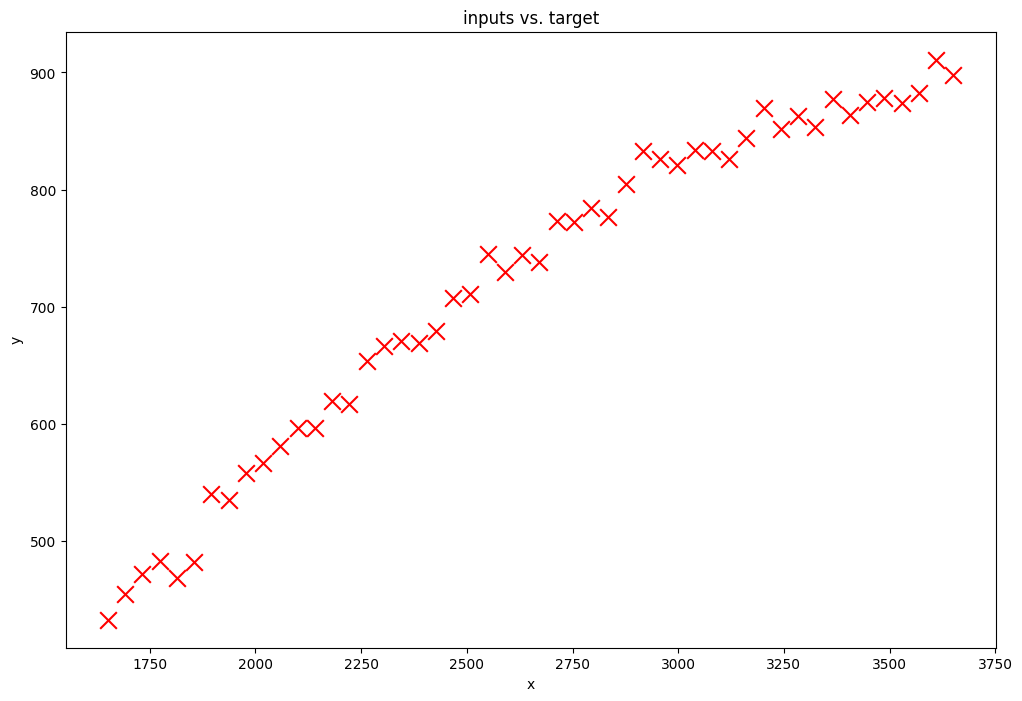

In [4]:
plot_dataset(x, y, "inputs vs. target") 

In [6]:
# Get 60 % of the dataset as the training set. Put the remaining 40% in the temporary variables
x_train, x_, y_train, y_ = train_test_split(x, y, test_size=0.4, random_state= 1) 

# Split the 40% subset above into two: one half for cross validation and the other for the test set
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.5, random_state=1)

del x_, y_

print(f"the shape of the training set (input) is {x_train.shape}")
print(f"the shape of the training set (target) is {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is {x_cv.shape}")
print(f"the shape of the cross validation (target) is {y_cv.shape}\n")
print(f"the shape of the test set (input) is {x_test.shape}")
print(f"the shape of the test set (target) is {y_test.shape}")

the shape of the training set (input) is (30, 1)
the shape of the training set (target) is (30, 1)

the shape of the cross validation set (input) is (10, 1)
the shape of the cross validation (target) is (10, 1)

the shape of the test set (input) is (10, 1)
the shape of the test set (target) is (10, 1)


In [7]:
def plot_train_cv_test(x_train, y_train, x_cv, y_cv, x_test, y_test): 
    plt.scatter(x_train, y_train, c='r', marker='x', label='training')
    plt.scatter(x_cv, y_cv, c='b', marker='o', label='cross validation')
    plt.scatter(x_test, y_test, c='g', marker='^', label= 'test set')
    plt.xlabel('x') 
    plt.ylabel('y') 
    plt.legend() 
    plt.title("input vs target")
    plt.show()

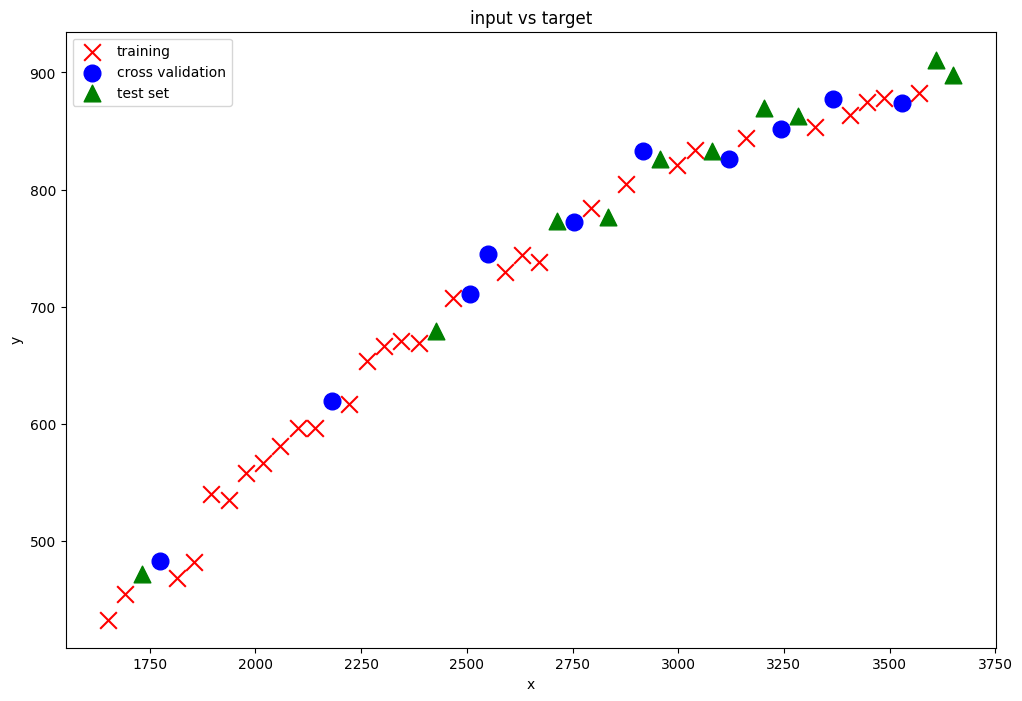

In [8]:
plot_train_cv_test(x_train, y_train, x_cv, y_cv, x_test, y_test)

# Fit a linear model

### Feature scaling 

You will only use x for this model but it's good to practice feature scaling now so you can apply it later. For that, you will use the `StandardScaler` class from scikit-learn

Computed mean of the training set: 2504.06
Computed standard deviation of the training set: 574.85


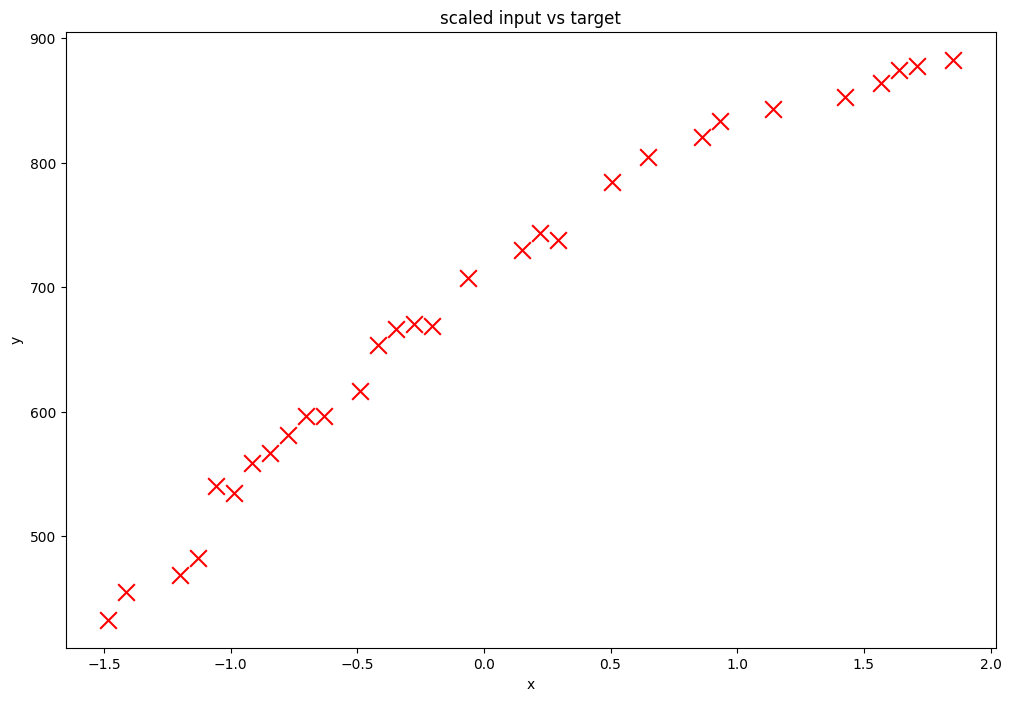

In [12]:
scaler_linear = StandardScaler() 

X_train_scaled = scaler_linear.fit_transform(x_train)

print(f"Computed mean of the training set: {scaler_linear.mean_.squeeze():.2f}")
print(f"Computed standard deviation of the training set: {scaler_linear.scale_.squeeze():.2f}")

plot_dataset(X_train_scaled, y_train, "scaled input vs target")

In [15]:
linear_model = LinearRegression()
print(linear_model)

linear_model.fit(X_train_scaled, y_train)

LinearRegression()


LinearRegression()

In [20]:
yhat = linear_model.predict(X_train_scaled)

print(f"the training MSE (using sklearn function): {(mean_squared_error(yhat, y_train)/2):.2f}")

total_squared_error = 0

for i in range(len(yhat)): 
    squared_error_i = (yhat[i] - y_train[i])**2 
    total_squared_error += squared_error_i

mse = total_squared_error / (2*len(yhat))
print(f"training MSE (for loop implementation): {mse.squeeze():.2f}")

the training MSE (using sklearn function): 406.19
training MSE (for loop implementation): 406.19


In [21]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_mapped = poly.fit_transform(x_train)

print(X_train_mapped[:5])

[[3.32e+03 1.11e+07]
 [2.34e+03 5.50e+06]
 [3.49e+03 1.22e+07]
 [2.63e+03 6.92e+06]
 [2.59e+03 6.71e+06]]


In [22]:
scaler_poly = StandardScaler() 

X_train_mapped_scaled = scaler_poly.fit_transform(X_train_mapped)

print(X_train_mapped_scaled[:5])

[[ 1.43  1.47]
 [-0.28 -0.36]
 [ 1.71  1.84]
 [ 0.22  0.11]
 [ 0.15  0.04]]


In [27]:
model = LinearRegression() 

model.fit(X_train_mapped_scaled, y_train)

yhat = model.predict(X_train_mapped_scaled)
print(f"Training MSE: {mean_squared_error(yhat, y_train)/2:.2f}")

X_cv_mapped = poly.transform(x_cv)
X_cv_mapped_scaled = scaler_poly.transform(X_cv_mapped)

yhat = model.predict(X_cv_mapped_scaled)
print(f"Cross validation MSE: {mean_squared_error(y_cv, yhat)/2:.2f}")

Training MSE: 49.11
Cross validation MSE: 87.70


In [32]:
def plot_train_cv_mses(degrees, train_mses, cv_mses, title): 
    degrees = range(1, 11)
    plt.plot(degrees, train_mses, marker = 'x', c = 'r', label = 'training MSEs') 
    plt.plot(degrees, cv_mses, marker='o', c = 'b', label = 'CV MSEs')
    plt.title(title) 
    plt.xlabel("degree") 
    plt.ylabel("MSE") 
    plt.legend() 
    plt.show()

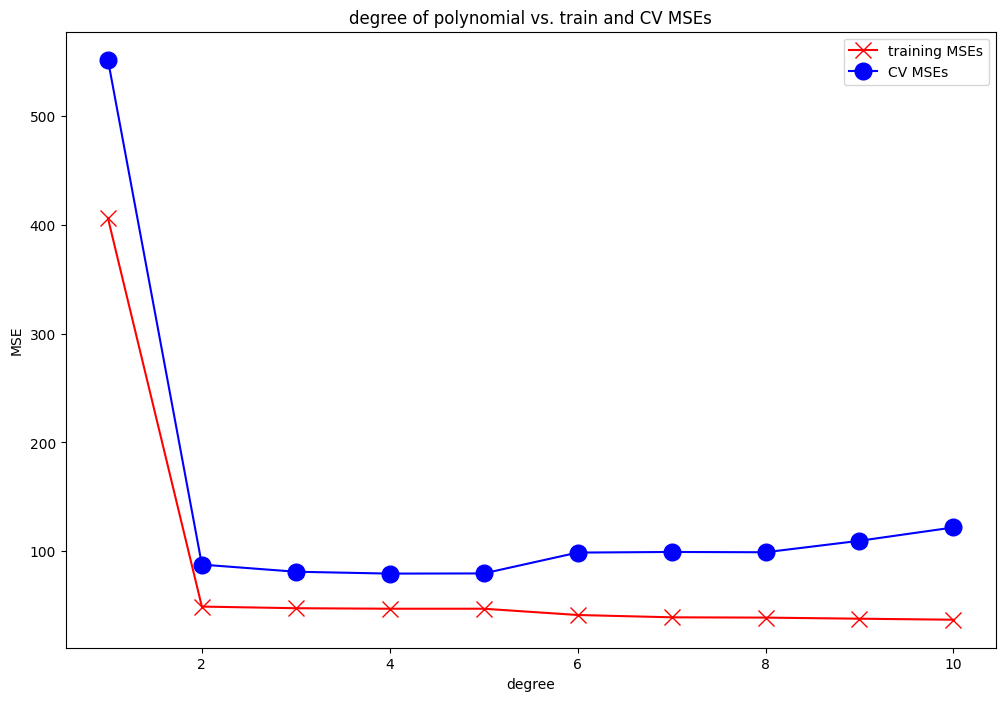

In [38]:
train_mses = []
cv_mses = []
models = []
polys = []
scalers = []

for degree in range(1, 11): 
    poly = PolynomialFeatures(degree, include_bias=False)
    X_train_mapped = poly.fit_transform(x_train)
    polys.append(poly)

    scaler_poly = StandardScaler()
    X_train_mapped_scaled  = scaler_poly.fit_transform(X_train_mapped) 
    scalers.append(scaler_poly)

    model = LinearRegression() 
    model.fit(X_train_mapped_scaled, y_train)
    models.append(model)

    yhat = model.predict(X_train_mapped_scaled)
    train_mse = mean_squared_error(y_train, yhat) / 2
    train_mses.append(train_mse)

    X_cv_mapped = poly.transform(x_cv)
    X_cv_mapped_scaled = scaler_poly.transform(X_cv_mapped)

    yhat = model.predict(X_cv_mapped_scaled)
    cv_mse = mean_squared_error(yhat, y_cv) / 2
    cv_mses.append(cv_mse)

degrees = range(1, 11) 
plot_train_cv_mses(degrees, train_mses, cv_mses, "degree of polynomial vs. train and CV MSEs")

In [40]:
degree = np.argmin(cv_mses) + 1
print(f"Lowest CV MSE is found in the model with degree of = {degree}")

Lowest CV MSE is found in the model with degree of = 4


In [41]:
X_test_mapped = polys[degree - 1].transform(x_test)

X_test_mapped_scaled = scalers[degree - 1].transform(X_test_mapped)

yhat = models[degree - 1].predict(X_test_mapped_scaled)
test_mse = mean_squared_error(y_test, yhat) / 2

print(f"Training MSE: {train_mses[degree - 1]:.2f}")
print(f"Cross validation MSE: {cv_mses[degree - 1]:.2f}")
print(f"Test MSE: {test_mse:.2f}")

Training MSE: 47.15
Cross validation MSE: 79.43
Test MSE: 104.63


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [76]:
degree = 1
poly = PolynomialFeatures(degree, include_bias=False)
X_train_mapped = poly.fit_transform(x_train)
X_cv_mapped = poly.transform(x_cv)
X_test_mapped = poly.transform(x_test)

In [77]:
scaler = StandardScaler()
X_train_mapped_scaled = scaler.fit_transform(X_train_mapped)
X_cv_mapped_scaled = scaler.transform(X_cv_mapped)
X_test_mapped_scaled = scaler.transform(X_test_mapped)

In [78]:
def build_models():
    
    tf.random.set_seed(20)
    
    model_1 = Sequential(
        [
            Dense(25, activation = 'relu'),
            Dense(15, activation = 'relu'),
            Dense(1, activation = 'linear')
        ],
        name='model_1'
    )

    model_2 = Sequential(
        [
            Dense(20, activation = 'relu'),
            Dense(12, activation = 'relu'),
            Dense(12, activation = 'relu'),
            Dense(20, activation = 'relu'),
            Dense(1, activation = 'linear')
        ],
        name='model_2'
    )

    model_3 = Sequential(
        [
            Dense(32, activation = 'relu'),
            Dense(16, activation = 'relu'),
            Dense(8, activation = 'relu'),
            Dense(4, activation = 'relu'),
            Dense(12, activation = 'relu'),
            Dense(1, activation = 'linear')
        ],
        name='model_3'
    )
    
    model_list = [model_1, model_2, model_3]
    
    return model_list

In [82]:
# Initialize lists that will contain the errors for each model
nn_train_mses = []
nn_cv_mses = []

# Build the models
nn_models = build_models()

# Loop over the the models
for model in nn_models:
    
    # Setup the loss and optimizer
    model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    )

    print(f"Training {model.name}...")
    
    # Train the model
    model.fit(
        X_train_mapped_scaled, y_train,
        epochs=300,
        verbose=0
    )
    
    print("Done!\n")

    
    # Record the training MSEs
    yhat = model.predict(X_train_mapped_scaled)
    train_mse = mean_squared_error(y_train, yhat) / 2
    nn_train_mses.append(train_mse)
    
    # Record the cross validation MSEs 
    yhat = model.predict(X_cv_mapped_scaled)
    cv_mse = mean_squared_error(y_cv, yhat) / 2
    nn_cv_mses.append(cv_mse)

    
# print results
print("RESULTS:")
for model_num in range(len(nn_train_mses)):
    print(
        f"Model {model_num+1}: Training MSE: {nn_train_mses[model_num]:.2f}, " +
        f"CV MSE: {nn_cv_mses[model_num]:.2f}"
        )

Training model_1...
Done!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Training model_2...
Done!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Training model_3...
Done!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
RESULTS:
Model 1: Training MSE: 109.18, CV MSE: 163.38
Model 2: Training MSE: 406.19, CV MSE: 551.78
Model 3: Training MSE: 69.11, CV MSE: 83.32


In [80]:
# Select the model with the lowest CV MSE
model_num = 3

# Compute the test MSE
print(X_test_mapped_scaled.shape)
yhat = nn_models[model_num-1].predict(X_test_mapped_scaled)
test_mse = mean_squared_error(y_test, yhat) / 2

print(f"Selected Model: {model_num}")
print(f"Training MSE: {nn_train_mses[model_num-1]:.2f}")
print(f"Cross Validation MSE: {nn_cv_mses[model_num-1]:.2f}")
print(f"Test MSE: {test_mse:.2f}")

(10, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Selected Model: 3
Training MSE: 83.94
Cross Validation MSE: 125.80
Test MSE: 121.59


In [84]:
data = np.loadtxt('./data/data_w3_ex2.csv', delimiter = ',')

x_bc = data[:, :-1]
y_bc = data[:, -1]

y_bc = y_bc.reshape(-1, 1) 

print(f"the shape of the inputs x is {x_bc.shape}")
print(f"the shape of the targets y is {y_bc.shape}")

the shape of the inputs x is (200, 2)
the shape of the targets y is (200, 1)


In [89]:
def plot_bc_dataset(x, y, title): 
    pos = y == 1
    neg = y == 0

    pos = pos.reshape(-1,) 
    neg = neg.reshape(-1,) 

    plt.scatter(x[pos, 0], x[pos, 1], marker = 'x', c ='r', label='y=1')
    plt.scatter(x[neg, 0], x[neg, 1], marker = 'o', c ='b', label='y=1')
    plt.title(title) 
    plt.xlabel('x1') 
    plt.ylabel('x2') 
    plt.legend() 
    plt.show()

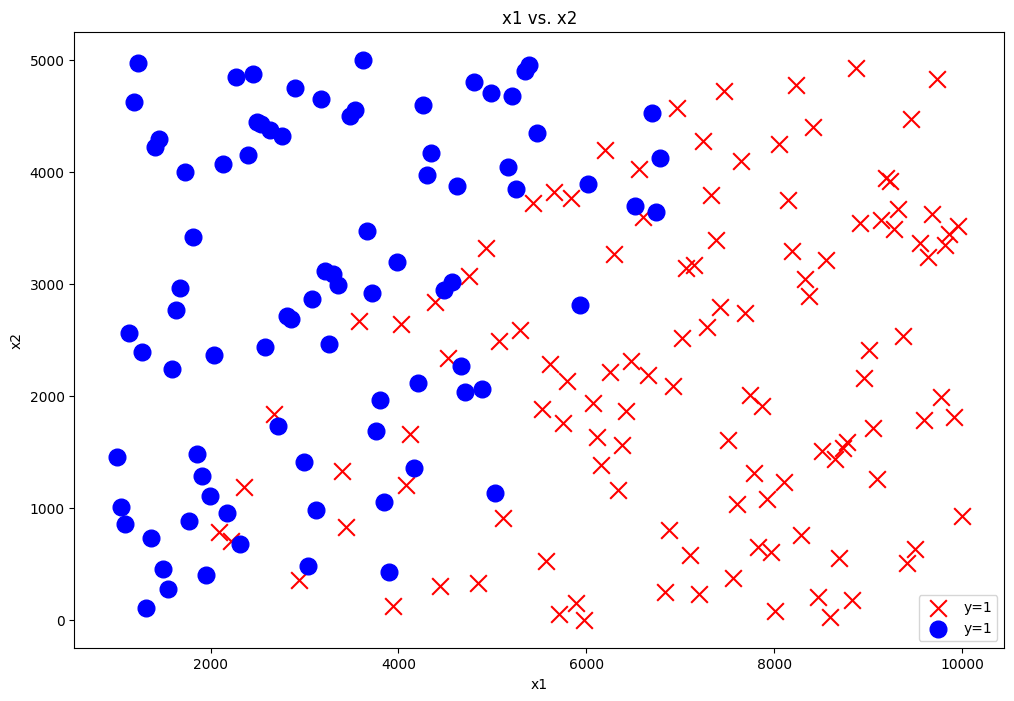

In [90]:
plot_bc_dataset(x_bc, y_bc, "x1 vs. x2")

In [95]:
from sklearn.model_selection import train_test_split

x_bc_train, x_, y_bc_train, y_ = train_test_split(x_bc, y_bc, test_size=0.4, random_state=1) 

x_bc_cv, x_bc_test, y_bc_cv, y_bc_test = train_test_split(x_, y_, test_size=0.5, random_state=1) 

del x_, y_

print(f"the shape of the training set (input) is {x_bc_train.shape}")
print(f"the shape of the training set (target) is {y_bc_train.shape}\n")
print(f"the shape of the cross validation set (input) is {x_bc_cv.shape}")
print(f"the shape of the cross validation set (target) is {y_bc_cv.shape}\n")
print(f"the shape of the test set (input) is {x_bc_test.shape}")
print(f"the shape of the test set (target) is {y_bc_test.shape}")

the shape of the training set (input) is (120, 2)
the shape of the training set (target) is (120, 1)

the shape of the cross validation set (input) is (40, 2)
the shape of the cross validation set (target) is (40, 1)

the shape of the test set (input) is (40, 2)
the shape of the test set (target) is (40, 1)


In [97]:
probabilities = np.array([0.2, 0.6, 0.7, 0.3, 0.8])

# Apply a threshold to the model output. If greater than 0.5, set to 1. Else 0
predictions = np.where(probabilities >= 0.5, 1, 0) 

#Ground truth labels 
ground_truth = np.array([1, 1, 1, 1, 1])

misclassfied = 0

num_predictions = len(predictions) 

for i in range(num_predictions): 
    if predictions[i] != ground_truth[i]: 
        misclassfied += 1

fraction_error = misclassfied / num_predictions
print(f"probabilities: {probabilities}")
print(f"prediction with threshold=0.5: {predictions}")
print(f"targets: {ground_truth}")
print(f"fraction of misclassfied data (for loop): {fraction_error}")
print(f"fraction of misclassfied data (with np.mean()) : {np.mean(predictions != ground_truth)}")

probabilities: [0.2 0.6 0.7 0.3 0.8]
prediction with threshold=0.5: [0 1 1 0 1]
targets: [1 1 1 1 1]
fraction of misclassfied data (for loop): 0.4
fraction of misclassfied data (with np.mean()) : 0.4


In [98]:
scaler_linear = StandardScaler() 

x_bc_train_scaled = scaler_linear.fit_transform(x_bc_train) 
x_bc_cv_scaled = scaler_linear.transform(x_bc_cv) 
x_bc_test_scaled = scaler_linear.transform(x_bc_test)

In [99]:
nn_train_error = []
nn_cv_error = []

models_bc = build_models() 

for model in models_bc: 
    model.compile(
        loss = tf.keras.losses.BinaryFocalCrossentropy(from_logits=True),
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
    ) 

    print(f"Training {model.name}...")

    model.fit(
        x_bc_train_scaled, y_bc_train, 
        epochs = 200, 
        verbose = 0
    )

    print("Done!\n")

    threshold = 0.5 
    yhat = model.predict(x_bc_train_scaled) 
    yhat = tf.math.sigmoid(yhat) 
    yhat = np.where(yhat >= threshold, 1, 0) 
    
    train_error = np.mean(yhat != y_bc_train)
    nn_train_error.append(train_error)

    yhat = model.predict(x_bc_cv_scaled) 
    yhat = tf.math.sigmoid(yhat) 
    yhat = np.where(yhat >= threshold, 1, 0) 
    cv_error = np.mean(yhat != y_bc_cv) 
    nn_cv_error.append(cv_error)

for model_num in range(len(nn_train_error)): 
    print(
        f"Model {model_num+1}: Training Set Classification Error: {nn_train_error[model_num]:.5f}, " +
        f"CV Set Classification Error: {nn_cv_error[model_num]:.5f}"
        )

Training model_1...
Done!

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Training model_2...
Done!

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Training model_3...
Done!

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Model 1: Training Set Classification Error: 0.03333, CV Set Classification Error: 0.15000
Model 2: Training Set Classification Error: 0.05833, CV Set Classification Error: 0.15000
Model 3: Training Set Classification Error: 0.09167, CV Set Classification Error: 0.05000


In [100]:
model_num = 3

yhat = models_bc[model_num - 1].predict(x_bc_test_scaled) 
yhat = tf.math.sigmoid(yhat) 
yhat = np.where(yhat >= threshold, 1, 0) 
nn_test_error = np.mean(yhat != y_bc_test)

print(f"Selected Model: {model_num}")
print(f"Training Set Classification Error: {nn_train_error[model_num-1]:.4f}")
print(f"CV Set Classification Error: {nn_cv_error[model_num-1]:.4f}")
print(f"Test Set Classification Error: {nn_test_error:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Selected Model: 3
Training Set Classification Error: 0.0917
CV Set Classification Error: 0.0500
Test Set Classification Error: 0.1250
